In [1]:
import pandas as pd
fp = "data/segmented_series.csv"
df = pd.read_csv(fp)

In [2]:
sel_s2 = df.segment == "segment-2"
df2 = df[sel_s2]

In [3]:
df2.shape

(165, 3)

In [4]:
df2

,date,signal,segment
211,2007-08-01,123.150870,segment-2
212,2007-09-01,128.043500,segment-2
213,2007-10-01,134.290870,segment-2
214,2007-11-01,131.045455,segment-2
215,2007-12-01,138.042857,segment-2
...,...,...,...
371,2020-12-01,157.952609,segment-2
372,2021-01-01,160.819524,segment-2
373,2021-02-01,166.429000,segment-2
374,2021-03-01,167.050870,segment-2


In [5]:
cols = ["date", "signal"]
df2 = df2[cols]

In [6]:
from ssalib import SingularSpectrumAnalysis

In [7]:
series = df2.signal
series.index = df2.date

In [8]:
# Create SSA instance and decompose
ssa = SingularSpectrumAnalysis(series)
ssa.decompose()


SingularSpectrumAnalysis(timeseries=<Series shape=(165,)>, window=82, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

In [9]:
ssa.groups

{'ssa_original': None, 'ssa_preprocessed': None, 'ssa_reconstructed': None}

In [10]:
from ssalib import SingularSpectrumAnalysis
from matplotlib import pyplot as plt
from typing import List

class SSADecomposition:
    def __init__(self, df: pd.DataFrame, window) -> None:
        if df.shape[1] == 3:
            cols = ["date","signal"]
            df = df[cols]
        self._df = df
        series = self._df.signal
        self._window = window
        series.index = self._df.date
        self._ssa = SingularSpectrumAnalysis(series, window=window)
        self._ssa.decompose()
        return

    def decomposition_plot(self, comp1: List[int], comp2: List[int] ) -> plt.Figure:
        self._ssa.reconstruct(groups={'Trend': comp1, 'Seasonal': comp2})
        fig, axes = ssa._ssa.plot(kind='timeseries',exclude=['ssa_preprocessed', 'ssa_reconstructed'],subplots=True)
        
        return fig

        
        
        

In [11]:
df = pd.read_csv(fp)
sel_s2 = df.segment == "segment-2"
df2 = df[sel_s2]

In [12]:
%matplotlib inline
ssa = SSADecomposition(df2,12)

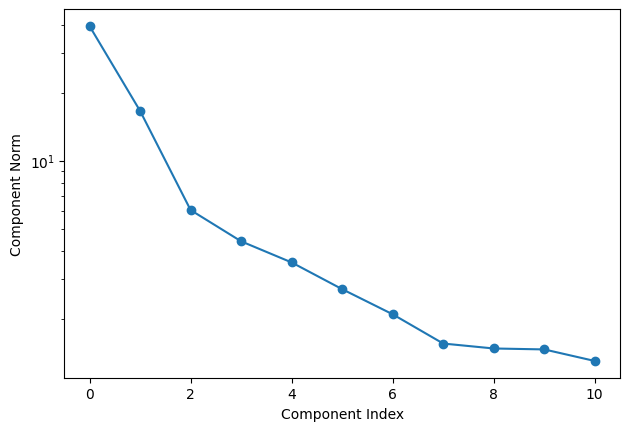

In [13]:
fig = ssa._ssa.plot(n_components=ssa._ssa._window -1, marker='o')

In [14]:
comp1 = [i for i in range(3)]
comp2 = [i for i in range(3,8)]

In [15]:
comp1

[0, 1, 2]

In [16]:
comp2

[3, 4, 5, 6, 7]

/tmp/ipykernel_26864/1609637343.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ssa.decomposition_plot(comp1, comp2).show()


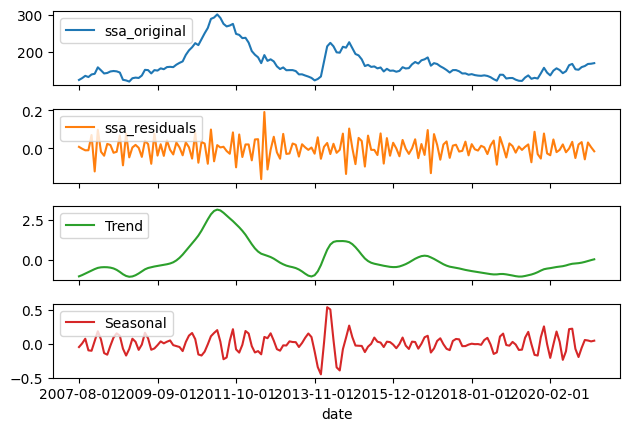

In [63]:
ssa.decomposition_plot(comp1, comp2).show()

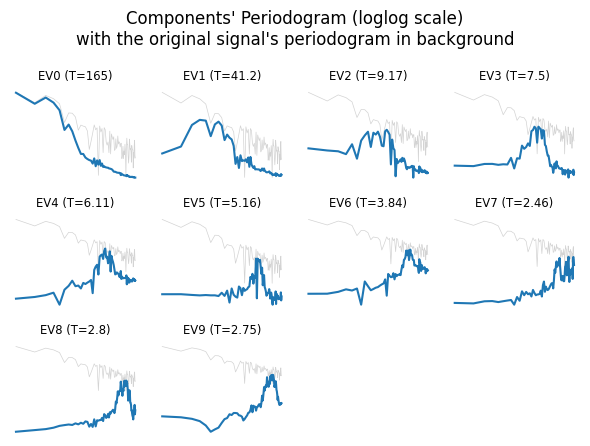

In [17]:

fig, axes = ssa._ssa.plot(kind='periodogram', scale='loglog')
fig.suptitle('Components\' Periodogram (loglog scale)\nwith the original signal\'s periodogram in background')
fig.tight_layout()

In [18]:
df2.shape[0]

165

In [22]:
ssa._ssa.groups

{'ssa_original': None, 'ssa_preprocessed': None, 'ssa_reconstructed': None}

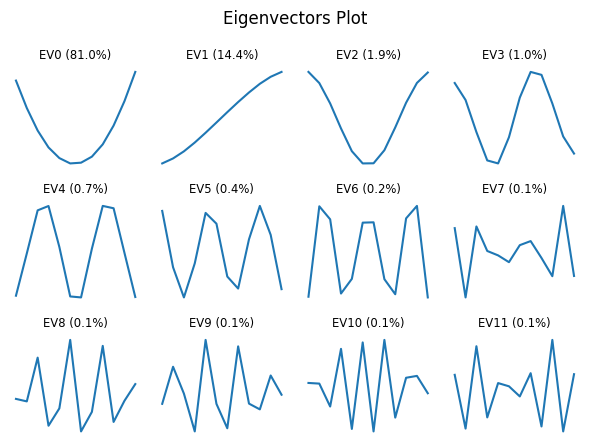

In [23]:
fig, axes = ssa._ssa.plot(kind='vectors')
fig.suptitle('Eigenvectors Plot')
fig.tight_layout()

In [25]:
ssa._ssa.n_components

12